In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'

In [3]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [4]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [5]:
NUM_CLASSES = len(np.unique(y_dataset))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout (Dropout)                    │ (None, 42)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 20)                  │             860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │              77 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,147 (4.48 KB)

 Trainable params: 1,147 (4.48 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)

es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
print(X_train.dtype)
print(y_train.dtype)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

float32
float64
(5024, 42)
(5024, 7)
(1675, 42)
(1675, 7)


In [13]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
25/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1353 - loss: 2.0428 
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1392 - loss: 2.0238 - val_accuracy: 0.2764 - val_loss: 1.8709
Epoch 2/1000
32/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1983 - loss: 1.8972 
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2038 - loss: 1.8923 - val_accuracy: 0.3164 - val_loss: 1.7787
Epoch 3/1000
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2803 - loss: 1.8145 
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2814 - loss: 1.8125 - val_accuracy: 0.4621 - val_loss: 1.6675
Epoch 4/1000
30/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3343 - loss: 1.7397 
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.kera

Epoch 25/1000
32/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6451 - loss: 0.9875 
Epoch 25: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6489 - loss: 0.9798 - val_accuracy: 0.9642 - val_loss: 0.4731
Epoch 26/1000
35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6538 - loss: 0.9627 
Epoch 26: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6539 - loss: 0.9625 - val_accuracy: 0.9654 - val_loss: 0.4842
Epoch 27/1000
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6736 - loss: 0.9163 
Epoch 27: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6730 - loss: 0.9176 - val_accuracy: 0.9582 - val_loss: 0.4618
Epoch 28/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6328 - loss: 0.9938
Epoch 28: saving model to model/keypoint_classifier/keypoint_classifi

Epoch 49/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6250 - loss: 0.9588
Epoch 49: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7005 - loss: 0.8189 - val_accuracy: 0.9576 - val_loss: 0.3353
Epoch 50/1000
30/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6893 - loss: 0.8382 
Epoch 50: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6942 - loss: 0.8288 - val_accuracy: 0.9594 - val_loss: 0.3291
Epoch 51/1000
28/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7079 - loss: 0.7929 
Epoch 51: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7073 - loss: 0.7949 - val_accuracy: 0.9630 - val_loss: 0.3261
Epoch 52/1000
30/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7186 - loss: 0.7875 
Epoch 52: saving model to model/keypoint_classifier/keypoint_classifi

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7373 - loss: 0.7304 - val_accuracy: 0.9636 - val_loss: 0.2883
Epoch 73/1000
33/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7237 - loss: 0.7392 
Epoch 73: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7261 - loss: 0.7384 - val_accuracy: 0.9731 - val_loss: 0.2734
Epoch 74/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7969 - loss: 0.5858
Epoch 74: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7388 - loss: 0.7282 - val_accuracy: 0.9630 - val_loss: 0.2910
Epoch 75/1000
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7446 - loss: 0.7288 
Epoch 75: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7438 - loss: 0.7298 - val_accuracy: 0.9713 - val_loss: 0.2748
Epoch 76/1000
29/40 ━━━━━━━━━━━━━━━━━━━━ 0

33/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7616 - loss: 0.6749 
Epoch 96: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7588 - loss: 0.6782 - val_accuracy: 0.9672 - val_loss: 0.2528
Epoch 97/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7344 - loss: 0.7272
Epoch 97: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7546 - loss: 0.6844 - val_accuracy: 0.9672 - val_loss: 0.2491
Epoch 98/1000
36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7563 - loss: 0.6830 
Epoch 98: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7556 - loss: 0.6856 - val_accuracy: 0.9618 - val_loss: 0.2540
Epoch 99/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8125 - loss: 0.5424
Epoch 99: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7612 - loss: 0.6480 - val_accuracy: 0.9660 - val_loss: 0.2404
Epoch 120/1000
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7588 - loss: 0.6718 
Epoch 120: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7588 - loss: 0.6702 - val_accuracy: 0.9630 - val_loss: 0.2317
Epoch 121/1000
32/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7689 - loss: 0.6681 
Epoch 121: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7675 - loss: 0.6669 - val_accuracy: 0.9612 - val_loss: 0.2339
Epoch 122/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7812 - loss: 0.6712
Epoch 122: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7663 - loss: 0.6453 - val_accuracy: 0.9600 - val_loss: 0.2402
Epoch 123/1000
36/40 ━━━━━━━━━━━━━━━

Epoch 143/1000
29/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7873 - loss: 0.6032 
Epoch 143: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7858 - loss: 0.6055 - val_accuracy: 0.9582 - val_loss: 0.2200
Epoch 144/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8359 - loss: 0.4884
Epoch 144: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7840 - loss: 0.5970 - val_accuracy: 0.9612 - val_loss: 0.2158
Epoch 145/1000
30/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7804 - loss: 0.6239 
Epoch 145: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7798 - loss: 0.6227 - val_accuracy: 0.9618 - val_loss: 0.2230
Epoch 146/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7422 - loss: 0.6642
Epoch 146: saving model to model/keypoint_classifier/keypoint_

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7836 - loss: 0.5852 - val_accuracy: 0.9666 - val_loss: 0.2080
Epoch 167/1000
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7812 - loss: 0.6706
Epoch 167: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7797 - loss: 0.6163 - val_accuracy: 0.9540 - val_loss: 0.2151
Epoch 168/1000
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7775 - loss: 0.6023 
Epoch 168: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7773 - loss: 0.6019 - val_accuracy: 0.9570 - val_loss: 0.2192
Epoch 169/1000
32/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7871 - loss: 0.6016 
Epoch 169: saving model to model/keypoint_classifier/keypoint_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7877 - loss: 0.6014 - val_accuracy: 0.9576 - val_loss: 0.2146
Epoch 170/1000
 1/40 ━━━━━━━━━━━━━━━

In [14]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9431 - loss: 0.2355 


In [15]:
model = tf.keras.models.load_model(model_save_path)

In [16]:
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[3.2646215e-04 5.7509830e-03 9.3161219e-01 1.5598433e-05 4.0257215e-03
 1.9937672e-03 5.6275249e-02]
2


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


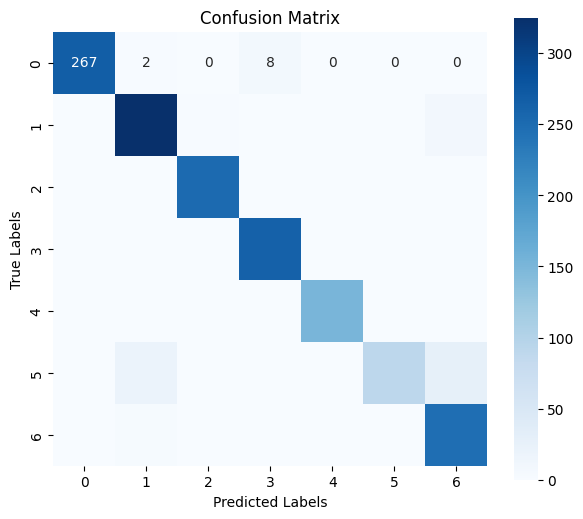

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       277
           1       0.93      0.97      0.95       336
           2       0.99      1.00      0.99       253
           3       0.97      1.00      0.98       264
           4       0.99      0.99      0.99       154
           5       1.00      0.65      0.78       141
           6       0.87      0.99      0.92       250

    accuracy                           0.95      1675
   macro avg       0.96      0.94      0.94      1675
weighted avg       0.96      0.95      0.95      1675



In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    if len(y_true.shape) > 1:
        y_true = np.argmax(y_true, axis=1)
    if len(y_pred.shape) > 1:
        y_pred = np.argmax(y_pred, axis=1)
    
    labels = np.unique(np.concatenate((y_true, y_pred)))
    
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g', cmap="Blues", square=True)
    ax.set_ylim(len(labels), 0)
    plt.ylabel('True Labels')
    plt.xlabel('Predicted Labels')
    plt.title('Confusion Matrix')
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_true, y_pred))


Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)


In [18]:
model_save_path = 'model/keypoint_classifier/keypoint_classifier_saved_model'
model.export(model_save_path)

INFO:tensorflow:Assets written to: model/keypoint_classifier/keypoint_classifier_saved_model\assets


INFO:tensorflow:Assets written to: model/keypoint_classifier/keypoint_classifier_saved_model\assets


Saved artifact at 'model/keypoint_classifier/keypoint_classifier_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2268312744560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268312744032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268312745264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268312740512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268312740160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2268312741920: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [19]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model(model_save_path)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_quantized_model = converter.convert()

tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'
open(tflite_save_path, 'wb').write(tflite_quantized_model)

print("Model successfully converted to TensorFlow Lite format!")

Model successfully converted to TensorFlow Lite format!


In [20]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [21]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [22]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [23]:
%%time
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 31.2 ms
Wall time: 0 ns


In [24]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[3.2646261e-04 5.7509937e-03 9.3161219e-01 1.5598478e-05 4.0257270e-03
 1.9937721e-03 5.6275301e-02]
2
